# Growth analytics: full analysis (SYNTHETIC)

> **Synthetic data.** Fictional freemium SaaS "Vaultly"; invented parameters; nothing here describes a real business. Every number below is computed by the code in this repository against the DuckDB warehouse (`make all` builds it).

Contents: A1 paid acquisition · A2 unit economics · A3 usage concentration · A4 free-tier limit · A5 retention · A6 upgrade propensity.

In [1]:
import pandas as pd
from IPython.display import Image, display
from src.analysis import a1_acquisition as a1, a2_unit_economics as a2, a3_concentration as a3, a4_limits as a4, a5_retention as a5
from src.analysis import charts as C
from src.analysis.common import connect, load_result, analysis_cfg
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 30); pd.options.display.float_format = '{:,.3f}'.format
con = connect(); cfg = analysis_cfg()
def show(fig, h=430):
    fig.update_layout(width=1000, height=h)
    display(Image(fig.to_image(format='png', scale=1.2)))

## A1. Paid acquisition
Spend, impressions, reach, frequency, CPM, CPC, CTR, landing-page-view rate, signup rate and cost per signup. **Ratios are ratios of sums** (total clicks / total impressions), never an average of row-level ratios.

In [2]:
by_country = a1.by_country(con)
by_country[['country_code','spend_eur','impressions','reach','frequency','cpm','cpc','ctr','lpv_rate','signup_rate','cost_per_signup','signups']]

,country_code,spend_eur,impressions,reach,frequency,cpm,cpc,ctr,lpv_rate,signup_rate,cost_per_signup,signups
0,US,"103,326.480","6,923,888.000","3,845,390.000",1.801,14.923,1.408,0.011,0.820,0.089,19.285,"5,358.000"
1,BR,"90,774.050","14,698,369.000","9,821,144.000",1.497,6.176,0.387,0.016,0.779,0.071,7.041,"12,893.000"
2,MX,"67,327.980","9,767,183.000","6,533,521.000",1.495,6.893,0.426,0.016,0.770,0.070,7.923,"8,498.000"
3,CO,"28,460.290","5,164,603.000","3,691,279.000",1.399,5.511,0.363,0.015,0.738,0.065,7.563,"3,763.000"
4,ES,"27,010.840","2,672,424.000","1,545,764.000",1.729,10.107,0.867,0.012,0.802,0.081,13.385,"2,018.000"
5,DE,"26,875.490","2,117,475.000","1,240,026.000",1.708,12.692,1.229,0.010,0.822,0.071,21.095,"1,274.000"
6,PE,"18,907.230","3,613,404.000","2,587,228.000",1.397,5.233,0.351,0.015,0.723,0.059,8.178,"2,312.000"
7,AR,"10,368.330","2,323,343.000","1,680,206.000",1.383,4.463,0.254,0.018,0.694,0.047,7.855,"1,320.000"


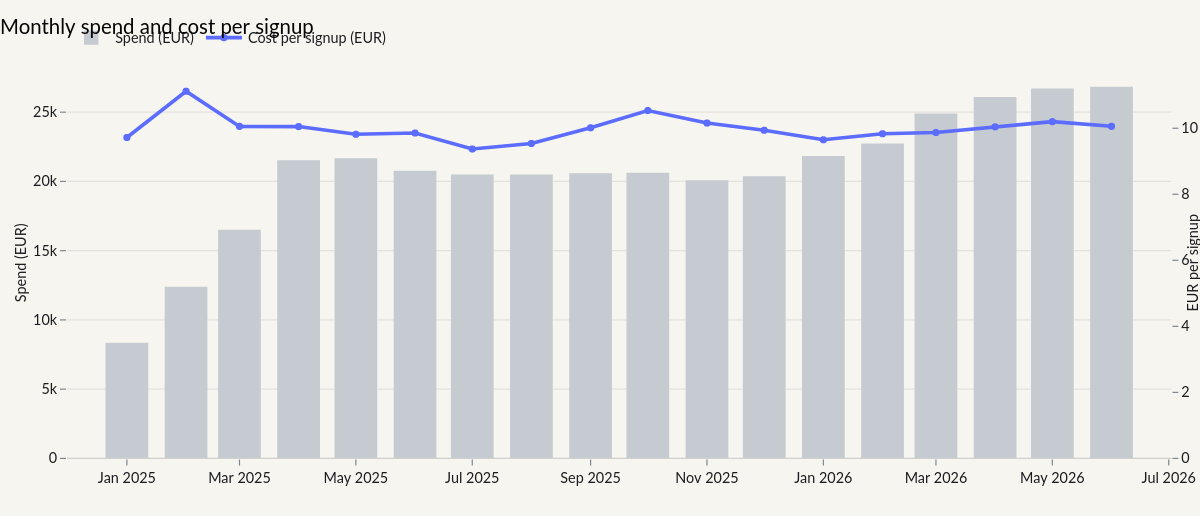

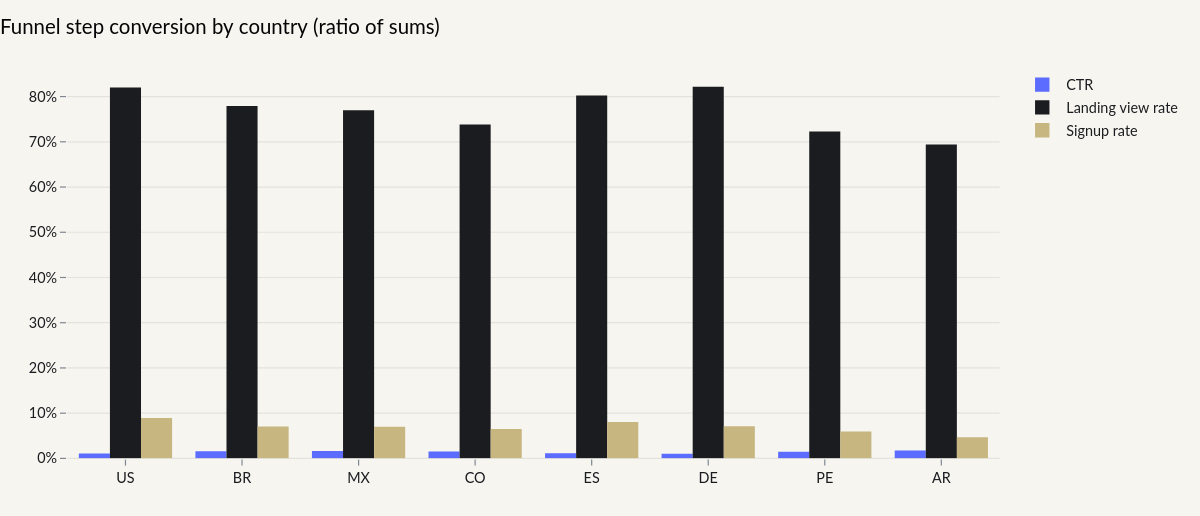

In [3]:
show(C.spend_monthly(a1.by_country_month(con)))
show(C.funnel_rates(by_country))

### BR vs MX
Two-proportion z-tests per funnel step and a bootstrap CI of the difference (resampling campaign × month rows). With millions of impressions the z-test flags almost any gap; the bootstrap respects clustering and is the more conservative read.

In [4]:
a1.compare_two(con, 'BR', 'MX')

,step,BR,MX,diff,z,p_value,boot_ci_low,boot_ci_high
0,CTR (clicks / impressions),0.016,0.016,-0.000,-4.741,0.000,-0.002,0.001
1,Landing view rate (views / clicks),0.779,0.770,0.009,6.895,0.000,0.003,0.015
2,Signup rate (signups / views),0.071,0.070,0.001,0.843,0.399,-0.005,0.007
3,Cost per signup (EUR),7.041,7.923,-0.882,NaN,NaN,-1.884,0.068


In [5]:
a1.pairwise_vs_reference(con, 'BR')

,country,signup_rate_BR,signup_rate_other,p_value,cost_per_signup_diff,diff_ci_low,diff_ci_high,p_holm
0,US,0.071,0.089,0.000,-12.244,-14.111,-10.426,0.000
1,MX,0.071,0.070,0.399,-0.882,-1.836,0.139,0.799
2,CO,0.071,0.065,0.000,-0.523,-1.448,0.399,0.000
3,ES,0.071,0.081,0.000,-6.344,-7.778,-4.955,0.000
4,DE,0.071,0.071,0.891,-14.055,-16.275,-11.846,0.891
5,PE,0.071,0.059,0.000,-1.137,-2.178,-0.112,0.000
6,AR,0.071,0.047,0.000,-0.814,-1.898,0.281,0.000


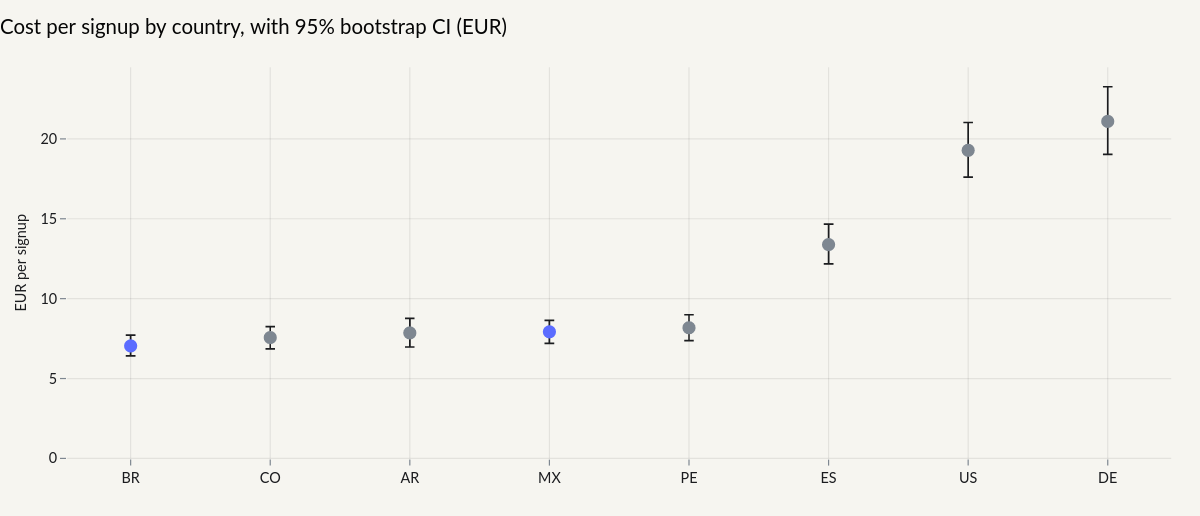

In [6]:
show(C.cost_per_signup_ci(a1.cost_per_signup_ci(con)))

## A2. Unit economics by country
**Cost per signup** prices a free account. **Paid CAC** (spend / paying customers, mature cohorts only) prices a paying customer. They are different numbers and are never mixed. LTV = ARPU × gross margin / monthly churn; payback = CAC / (ARPU × margin).

In [7]:
ue = a2.table(con, cfg)
ue[['country_code','cost_per_signup','paid_cac','paid_cac_low','paid_cac_high','arpu','monthly_churn','ltv','ltv_cac','payback_months','paying_customers']]

,country_code,cost_per_signup,paid_cac,paid_cac_low,paid_cac_high,arpu,monthly_churn,ltv,ltv_cac,payback_months,paying_customers
0,US,19.285,313.791,277.880,355.719,65.372,0.032,"1,656.533",5.279,6.000,260.000
1,ES,13.385,374.661,289.176,494.673,58.263,0.048,973.727,2.599,8.038,57.000
2,DE,21.095,473.905,353.014,652.221,63.107,0.051,997.298,2.104,9.387,44.000
3,MX,7.923,246.089,215.504,282.325,35.590,0.070,409.356,1.663,8.643,218.000
4,BR,7.041,245.861,219.002,276.982,32.015,0.080,319.724,1.300,9.599,287.000
5,CO,7.563,319.655,253.004,410.052,28.129,0.077,293.533,0.918,14.205,70.000
6,PE,8.178,370.885,272.366,519.145,28.436,0.099,230.609,0.622,16.304,40.000
7,AR,7.855,409.928,265.426,671.105,20.500,0.117,139.683,0.341,24.996,20.000


{'paid_cac': 294.59084337349395, 'arpu': 48.860805940585664, 'monthly_churn': 0.05644890038290802, 'ltv': 692.4606943150314, 'ltv_cac': 2.3505845816025666, 'payback_months': 7.536481380692789}


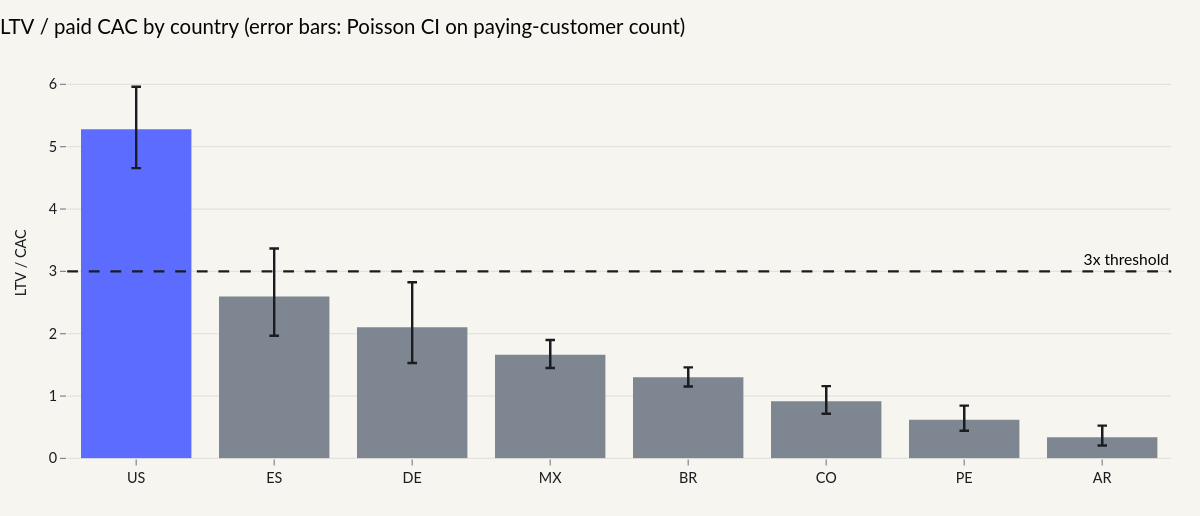

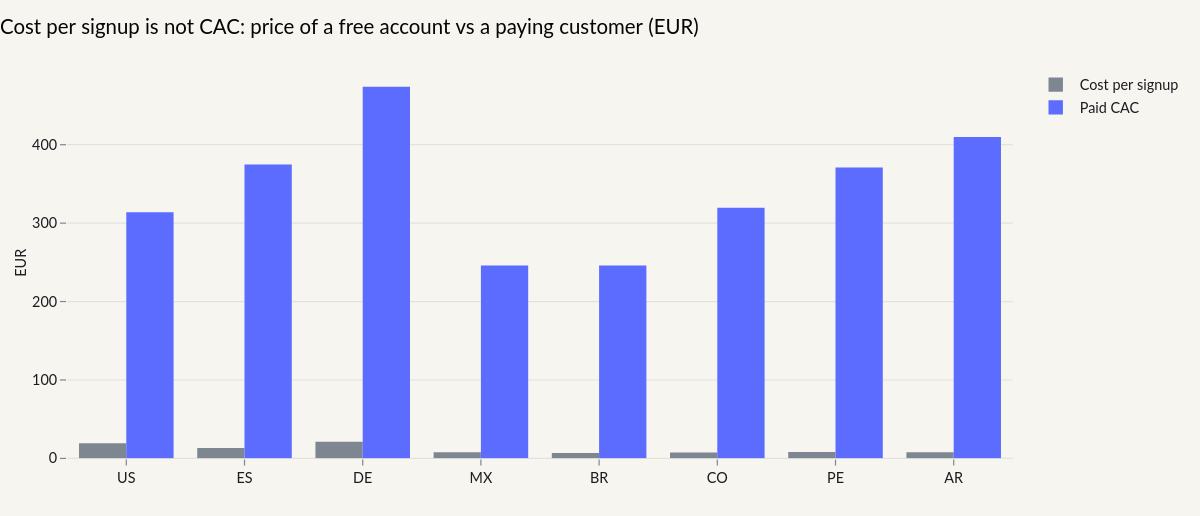

In [8]:
print(a2.blended(ue, cfg['unit_economics']['gross_margin']))
show(C.ltv_cac(ue, cfg['unit_economics']['target_ltv_cac']))
show(C.cost_vs_cac(a2.cost_vs_cac(ue)))

### Sensitivity
LTV/CAC when churn and CAC move ±25% / ±20%.

In [9]:
sens = a2.sensitivity(ue, cfg)
for c in ['US', 'BR']:
    display(a2.sensitivity_matrix(sens, c))

cac_x,0.800,1.000,1.200
churn_x,,,
0.750,8.800,7.040,5.870
1.000,6.600,5.280,4.400
1.250,5.280,4.220,3.520


cac_x,0.800,1.000,1.200
churn_x,,,
0.750,2.170,1.730,1.440
1.000,1.630,1.300,1.080
1.250,1.300,1.040,0.870


## A3. Usage concentration
Pareto cutoffs, quartiles, IQR long tail, bands of active days, 30d vs 90d windows (relative to the as-of date), by country and signup cohort.

In [10]:
a3.pareto_cutoffs(con)

,window_days,cutoff,users_needed,active_users,pct_users_needed
0,30,0.500,1938,26091,0.074
1,30,0.750,6277,26091,0.241
2,30,0.800,7786,26091,0.298
3,30,0.900,12282,26091,0.471
4,30,0.950,16076,26091,0.616
5,90,0.500,2264,34124,0.066
6,90,0.750,7481,34124,0.219
7,90,0.800,9362,34124,0.274
8,90,0.900,15021,34124,0.440
9,90,0.950,19884,34124,0.583


In [11]:
a3.quartiles(con)

,window_days,usage_quartile,users,total_assets,share_of_volume,min_assets,max_assets
0,30,1,6523,"24,891.000",0.021,1.000,7.000
1,30,2,6523,"77,067.000",0.066,7.000,17.000
2,30,3,6523,"177,523.000",0.153,17.000,41.000
3,30,4,6522,"879,853.000",0.759,41.000,"6,119.000"
4,90,1,8531,"56,707.000",0.017,1.000,14.000
5,90,2,8531,"201,234.000",0.059,14.000,36.000
6,90,3,8531,"491,223.000",0.145,36.000,89.000
7,90,4,8531,"2,646,529.000",0.779,89.000,"14,355.000"


In [12]:
a3.distribution(con).query("country_code == 'ALL'")

,window_days,country_code,users,q1,median,q3,p95,p99,max_assets,mean_assets,iqr,upper_fence,users_beyond_fence,volume_share_beyond_fence
0,30,ALL,26091,7.000,17.000,41.000,153.000,453.200,"6,119.000",44.434,34.000,92.000,2489,0.548
9,90,ALL,34124,14.000,36.000,89.000,334.000,"1,040.770","14,355.000",99.510,75.000,201.500,3426,0.580


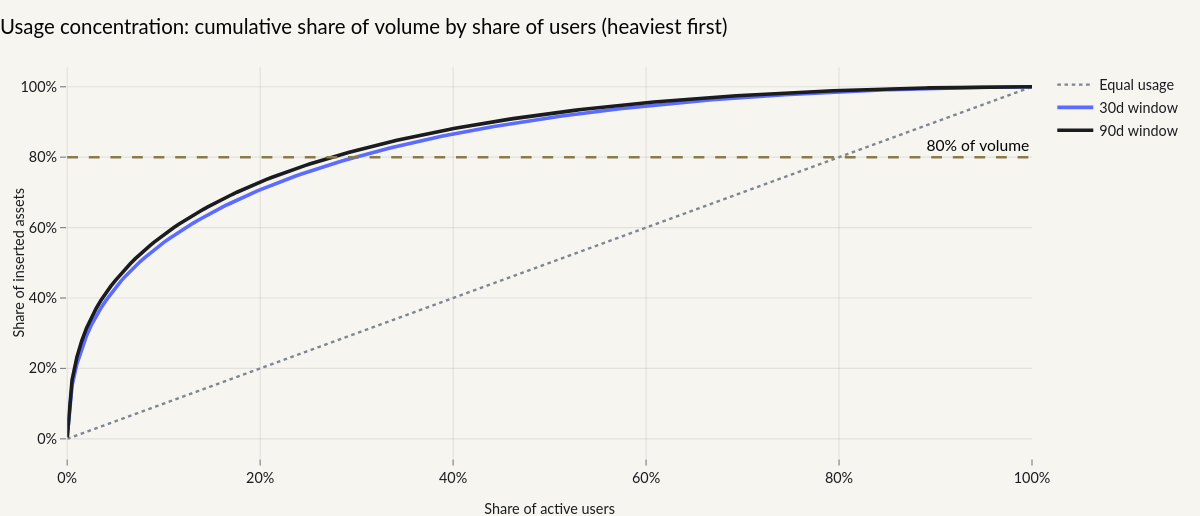

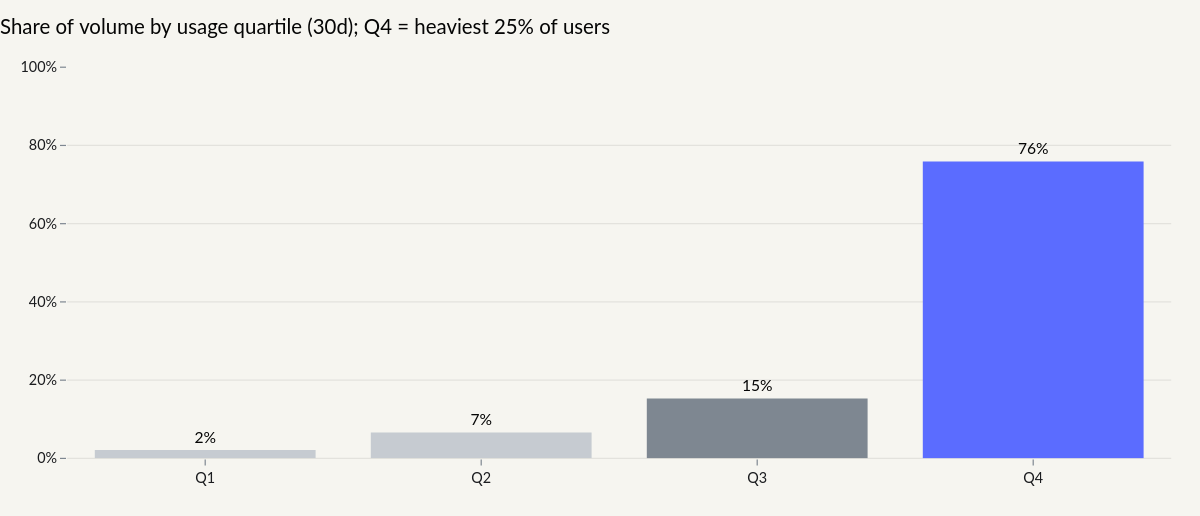

In [13]:
users = {w: a3.user_level(con, w) for w in (30, 90)}
show(C.lorenz({w: a3.lorenz_points(u) for w, u in users.items()}))
show(C.quartile_volume(a3.quartiles(con), 30))

Freedman-Diaconis bin width 2.02 bins 175


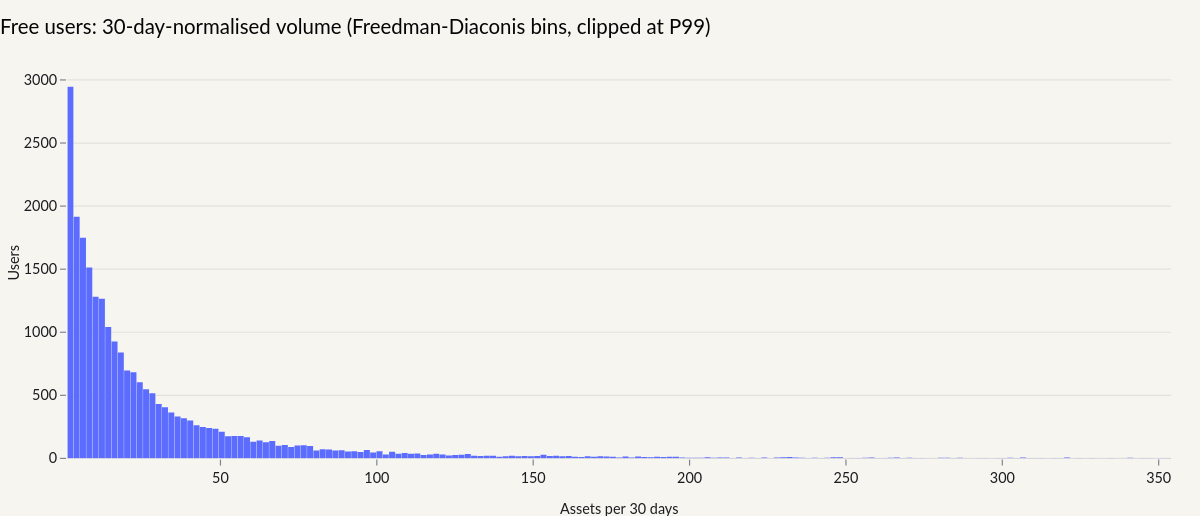

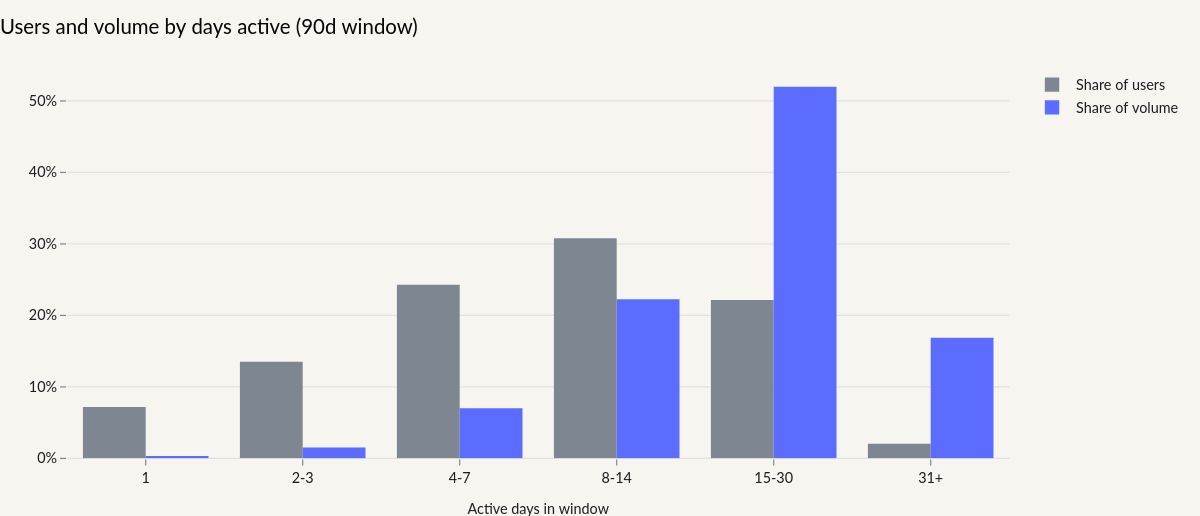

In [14]:
free30 = a3.user_level(con, 30, free_only=True)
h = a3.monthly_histogram(free30)
print('Freedman-Diaconis bin width', round(h['bin_width'], 2), 'bins', h['bins'])
show(C.histogram(h))
show(C.active_day_bands(a3.active_day_bands(con), 90))

In [15]:
a3.by_country_cohort(con).query('window_days == 90').head(16)

,window_days,country_code,signup_year,active_users,top80_users,top80_user_share,assets_per_active_user
16,90,AR,2025,379,105,0.277,72.530
17,90,AR,2026,854,199,0.233,73.320
18,90,BR,2025,3287,1093,0.333,113.801
19,90,BR,2026,7178,1770,0.247,91.217
20,90,CO,2025,1029,336,0.327,104.431
21,90,CO,2026,2097,499,0.238,95.283
22,90,DE,2025,588,214,0.364,117.469
23,90,DE,2026,1188,282,0.237,98.834
24,90,ES,2025,671,235,0.350,123.852
25,90,ES,2026,1351,349,0.258,83.155


## A4. Free-tier limit simulation
The usage side is measured. The monetisation layer is **assumption-driven** (low / base / high scenarios in `config/analysis.yaml`).

In [16]:
a4.candidates(con)

,limit_type,statistic,candidate
0,daily,Q3 of max daily insertions,14.000
1,daily,P90 of max daily insertions,27.000
2,daily,P95 of max daily insertions,41.000
3,monthly,Q3 of 30d insertions,37.000
4,monthly,P90 of 30d insertions,77.000
5,monthly,P95 of 30d insertions,126.000


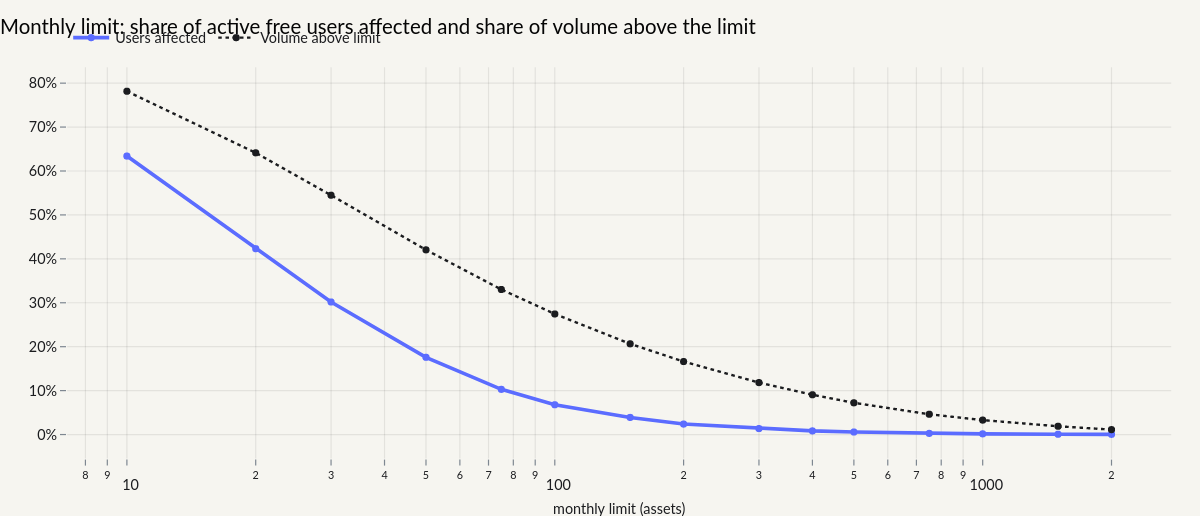

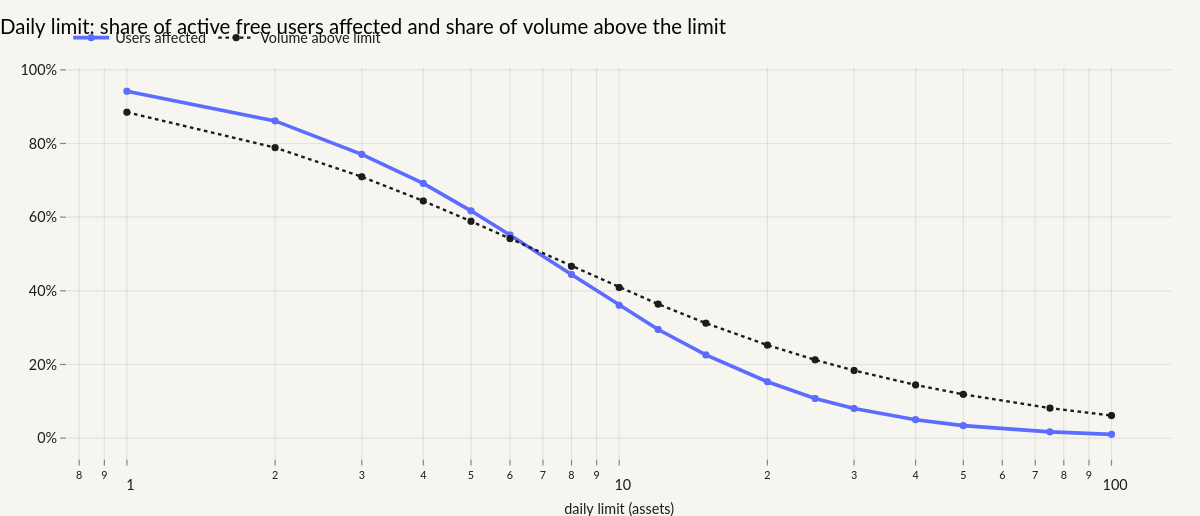

In [17]:
show(C.limit_curves(a4.simulation_grid(con), 'monthly'))
show(C.limit_curves(a4.simulation_grid(con), 'daily'))

In [18]:
sg = a4.scenario_grid(con, cfg)
rec = a4.recommend(sg, cfg)
rec

{'limit_type': 'monthly',
 'limit_value': 50.0,
 'pct_users_affected': 0.17582784218867295,
 'incremental_mrr_by_scenario': {'low': -1516.8658764230647,
  'base': 1519.995308942338,
  'high': 4726.390617884676},
 'scenario_optima': {'low': {'limit_type': 'monthly',
   'limit_value': 2000.0,
   'incremental_mrr': -4.7906593692447},
  'base': {'limit_type': 'monthly',
   'limit_value': 50.0,
   'incremental_mrr': 1519.995308942338},
  'high': {'limit_type': 'monthly',
   'limit_value': 50.0,
   'incremental_mrr': 4726.390617884676}},
 'guardrail': 0.2,
 'robust_positive': False,
 'note': 'Usage effects are measured; conversion, loss and user value are scenario assumptions.'}

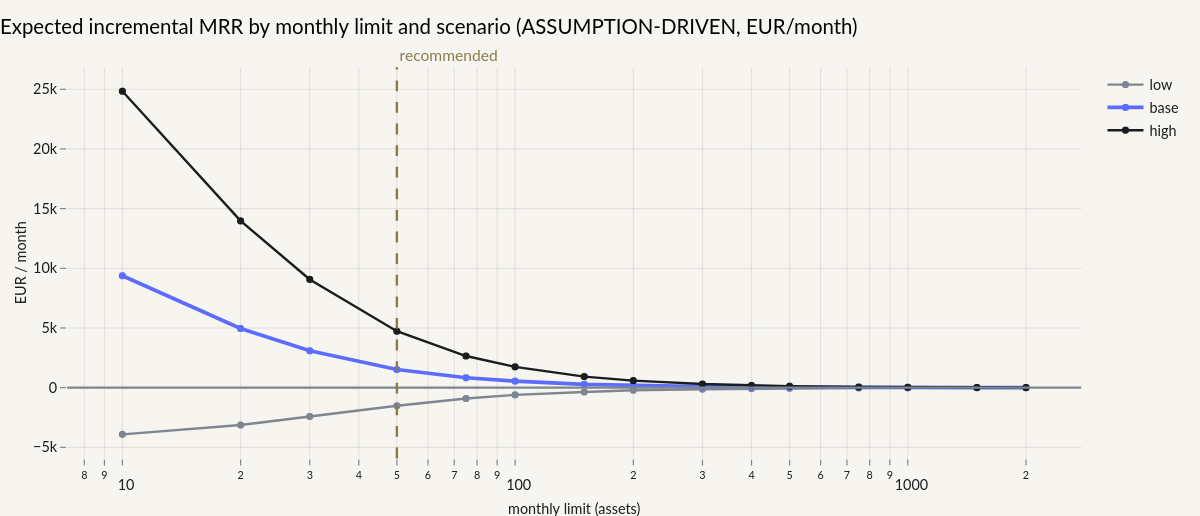

In [19]:
show(C.mrr_scenarios(sg, rec['limit_type'], recommended=rec['limit_value']))

In [20]:
sg[(sg.limit_type == rec['limit_type']) & (sg.pct_users_affected <= 0.35)].pivot(index='limit_value', columns='scenario', values='incremental_mrr')[['low','base','high']]

scenario,low,base,high
limit_value,,,
30,"-2,412.542","3,087.265","9,069.331"
50,"-1,516.866","1,519.995","4,726.391"
75,-910.832,831.340,"2,649.479"
100,-600.977,546.317,"1,743.035"
150,-359.661,277.687,928.973
200,-215.341,182.368,593.535
300,-129.935,85.923,302.246
400,-79.552,51.860,183.320
500,-56.288,33.159,121.518


**Reading this.** The recommended limit maximises base-scenario incremental MRR *subject to a guardrail* on the share of active free users affected. Without the guardrail the modelled MRR keeps rising as the limit tightens, because conversion is linear in the share of usage blocked; the guardrail, not the data, bounds the answer. In the low scenario the same limit loses money: treat the recommendation as a hypothesis to A/B test, not a forecast.

## A5. Retention
Monthly paid churn by country, cohort retention triangle, survival curves (Kaplan-Meier, censored at the as-of date).

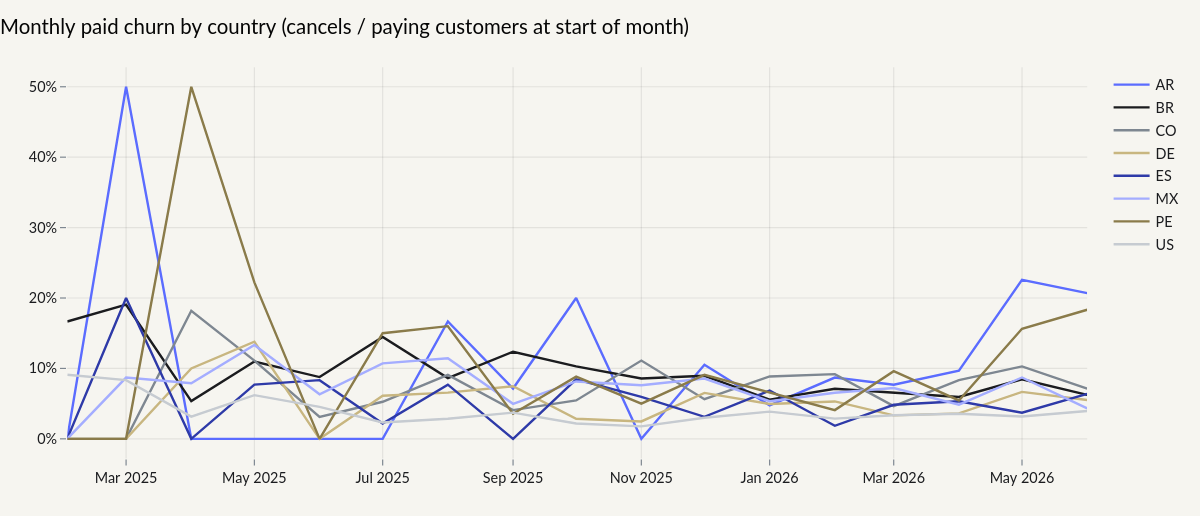

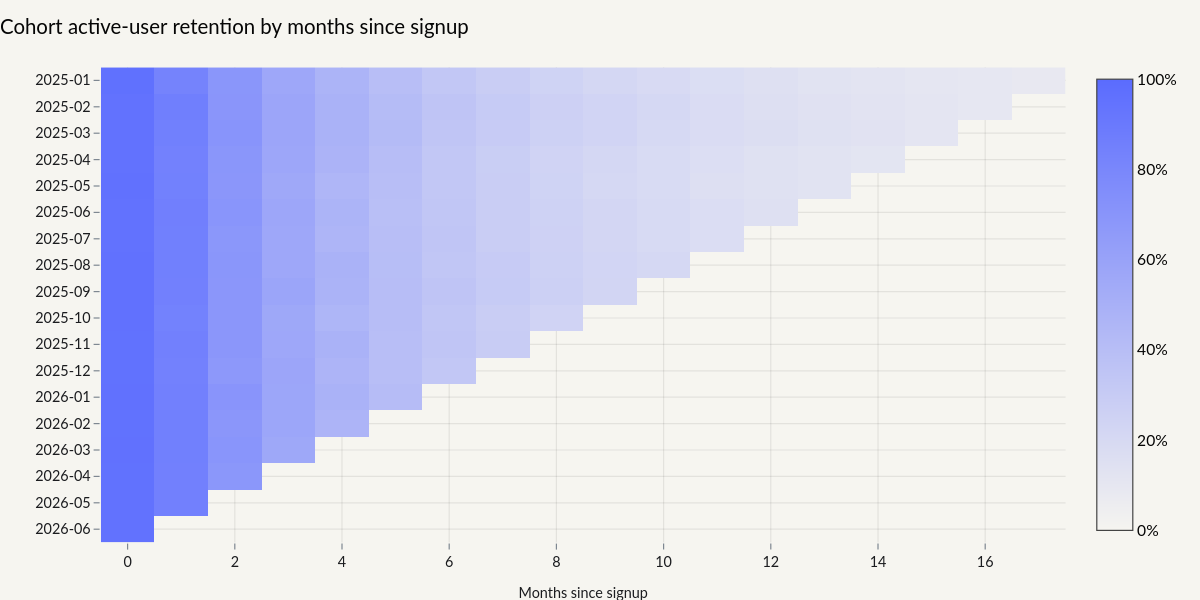

In [21]:
show(C.churn_by_country(a5.churn_by_country_month(con).query('paying_at_start > 0')))
show(C.triangle(a5.cohort_triangle(con)), 500)

,country,S(30d),S(90d),S(180d)
0,ALL,0.935,0.840,0.709
1,AR,0.890,0.751,0.474
2,BR,0.908,0.775,0.605
3,CO,0.909,0.867,0.709
4,DE,0.952,0.853,0.733
5,ES,0.910,0.823,0.764
6,MX,0.940,0.812,0.654
7,PE,0.909,0.718,0.525
8,US,0.964,0.916,0.830


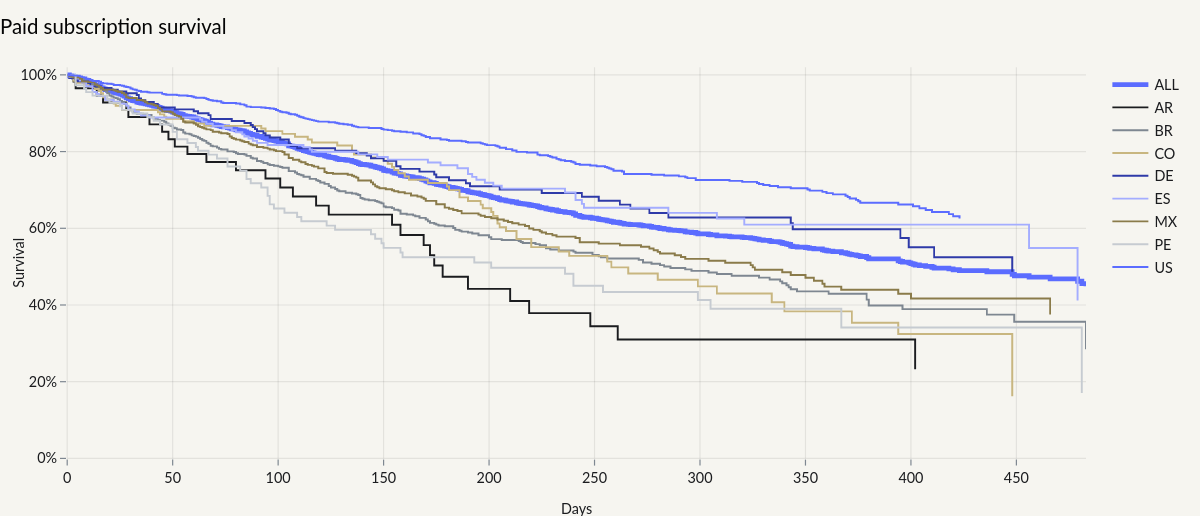

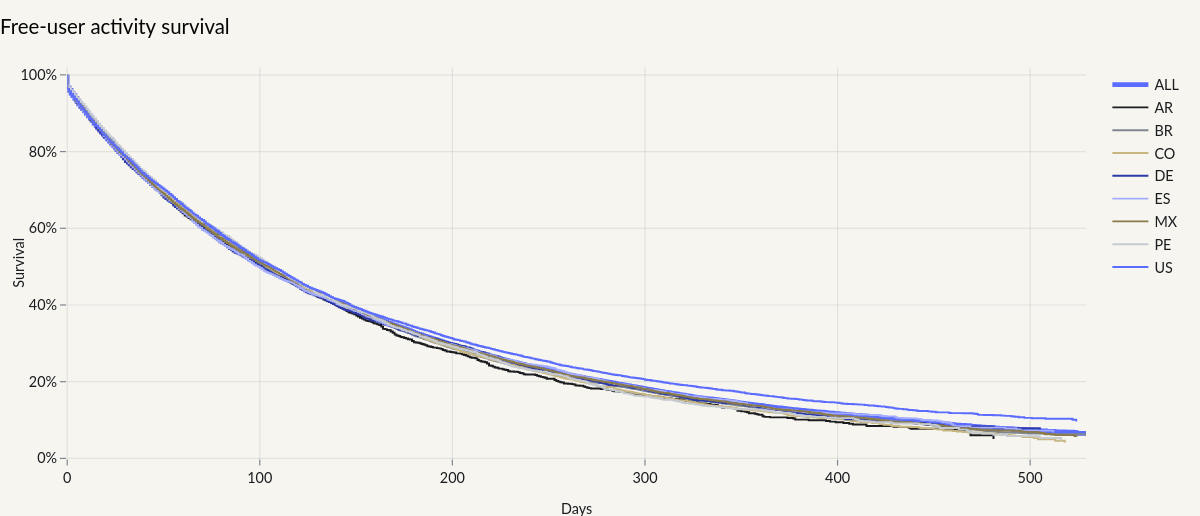

In [22]:
paid = a5.survival_curves(con, 'paid'); act = a5.survival_curves(con, 'activity')
display(a5.survival_table(paid))
show(C.survival(paid, 'Paid subscription survival'))
show(C.survival(act, 'Free-user activity survival'))

## A6. Upgrade-propensity model
Target: converts to paid in the **next 30 days**. Features: only the **prior** 60 days. Time-based split with purged training windows. Models: logistic regression vs gradient boosting; selected on the validation fold; threshold chosen by expected profit. Training is done by `python -m src.model`; this section reads the stored results.

In [23]:
m = load_result(con, 'propensity')
pd.DataFrame([{'model': k, **{f'{s} {kk}': vv for s in ('validation','test') for kk, vv in v[s].items() if kk in ('pr_auc','roc_auc','brier')}} for k, v in m['comparison'].items()])

,model,validation pr_auc,validation roc_auc,validation brier,test pr_auc,test roc_auc,test brier
0,logistic_regression,0.108,0.908,0.006,0.105,0.897,0.006
1,gradient_boosting,0.114,0.912,0.006,0.108,0.906,0.006
2,gradient_boosting_calibrated,0.112,0.915,0.006,0.092,0.904,0.006


In [24]:
print('chosen:', m['chosen'], '| threshold', round(m['threshold'], 4), '| break-even precision', round(m['break_even_precision'], 4))
print(m['profit_test'])
pd.DataFrame(m['lift_table'])

chosen: gradient_boosting_calibrated | threshold 0.0146 | break-even precision 0.0089
{'threshold_policy_eur': 12396.2, 'contact_all_eur': -9667.2, 'contacted': 11422, 'of': 78843, 'converters_reached': 377, 'converters_total': 486}


,decile,users,converters,avg_score,conversion_rate,lift,cum_capture
0,1,7885,332,0.045,0.042,6.831,0.683
1,2,7884,78,0.011,0.010,1.605,0.844
2,3,7884,39,0.004,0.005,0.802,0.924
3,4,7884,17,0.002,0.002,0.350,0.959
4,5,7884,13,0.001,0.002,0.267,0.986
5,6,7885,3,0.001,0.000,0.062,0.992
6,7,7884,2,0.000,0.000,0.041,0.996
7,8,7884,1,0.000,0.000,0.021,0.998
8,9,7884,1,0.000,0.000,0.021,1.000
9,10,7885,0,0.000,0.000,0.000,1.000


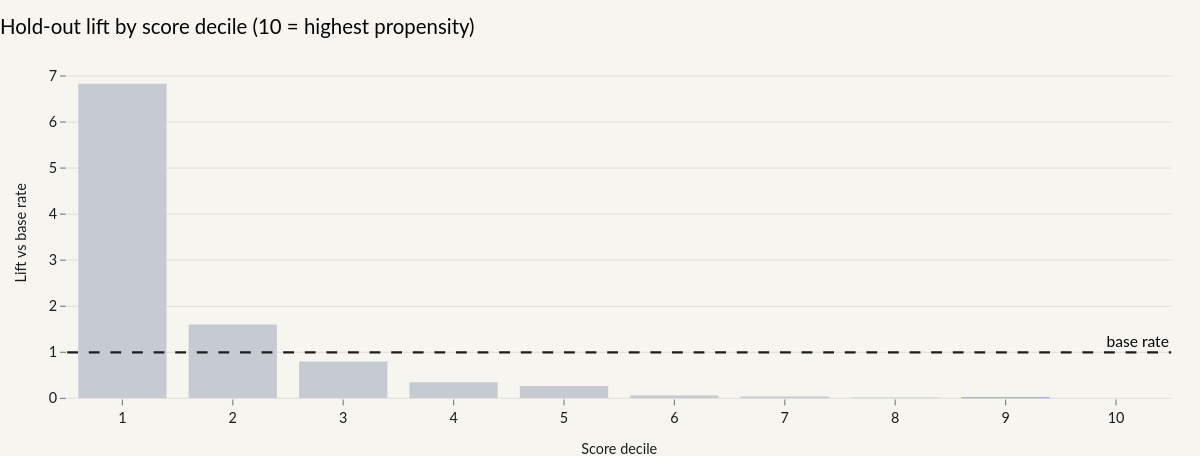

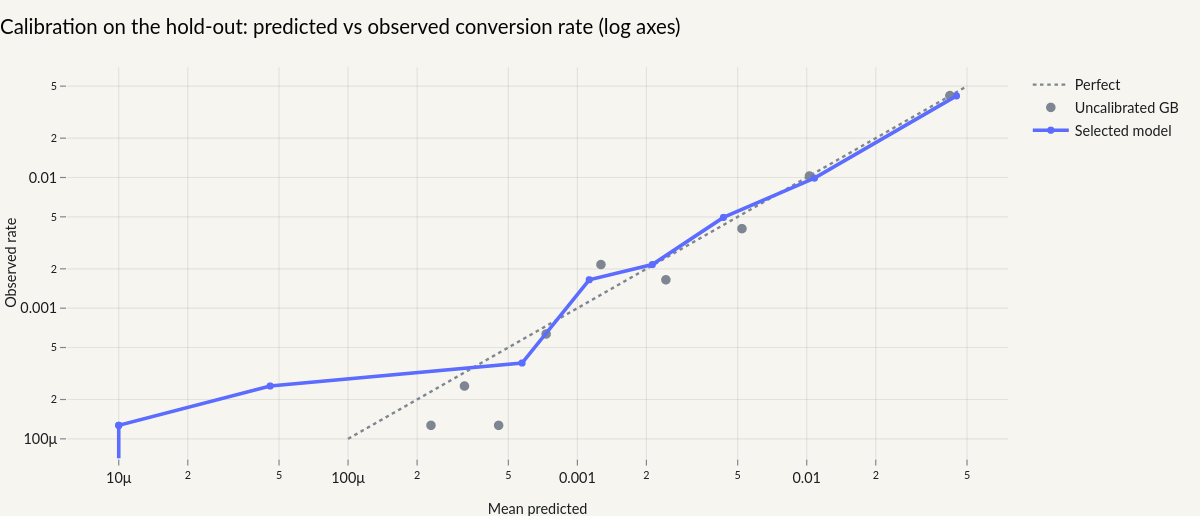

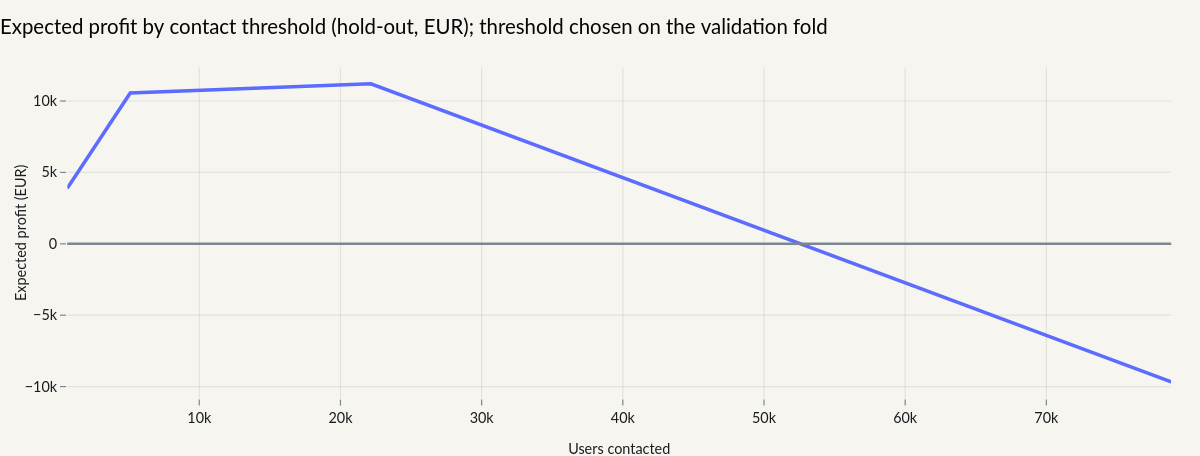

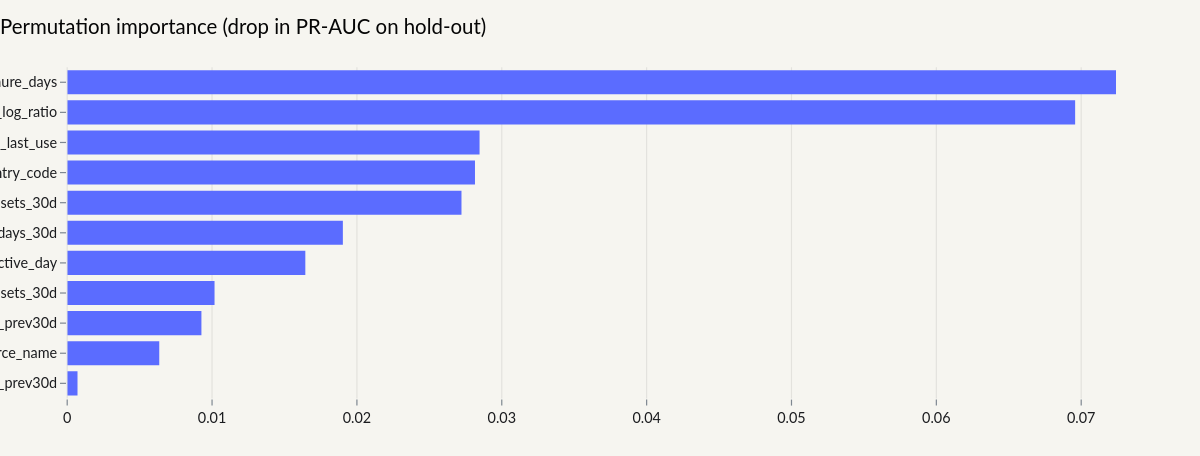

In [25]:
show(C.lift(pd.DataFrame(m['lift_table'])), 380)
show(C.calibration(pd.DataFrame(m['calibration']['calibrated_gb_or_lr']), pd.DataFrame(m['calibration']['raw_gb'])))
show(C.profit(pd.DataFrame(m['profit_curve_test']), m['threshold']), 380)
show(C.importance(pd.DataFrame(m['importance'])), 380)

### Why the target must not be built from a feature
The leaky variant below defines the label from `assets_30d` and also feeds `assets_30d` to the model. It looks superb and means nothing.

In [26]:
m['leakage_demo']

{'leaky_target': 'assets_30d >= P95 (feature used to define the label)',
 'leaky_pr_auc': 0.9998540510268399,
 'leaky_roc_auc': 0.9999925313893292,
 'honest_pr_auc_reference': None}

---
*All data in this notebook is synthetic.*